# Multi-Domain Issue Classification and Decision Support

This notebook presents an **end-to-end workflow** for classifying issue reports from multiple departments within a consulting firm.

---

### Project Overview
The goal of this project is to automate the classification of unstructured issue reports into predefined categories such as:
**Cybersecurity**, **Marketing**, **Data & AI**, **Cloud Infrastructure**, and **IT Operations**.

We use a **synthetic dataset** generated through Azure OpenAI prompts, containing:
- 1,000 issues (200 per department)
- Fields: `issue_id`, `description`, `category`, `priority`, and `created_at`

Each issue describes a realistic operational problem, with balanced distribution across departments and priorities.

---

### Objectives
- Explore and analyze the dataset distribution.  
- Train multiple classification models and compare results.  
- Evaluate model performance using F1, precision, recall, and accuracy.  
- Fine-tune a **SentenceTransformer (MiniLM)** model on the dataset to improve semantic performance.  
- Compare pre-trained vs. fine-tuned embeddings with **kNN** classification.

---

### Models Evaluated
| Model | Description |
|--------|--------------|
| TF-IDF + Logistic Regression | Interpretable classical baseline |
| TF-IDF + SVM | Strong linear classifier |
| TF-IDF + XGBoost | Non-linear ensemble approach |
| SBERT + kNN | Semantic, embedding-based method |
| Azure OpenAI Embeddings + kNN | LLM-based semantic embeddings |
| Fine-Tuned MiniLM + kNN | Domain-adapted embedding model |

---

### Workflow Summary
1. **Data Understanding** – Explore dataset structure and balance.  
2. **Preprocessing** – Clean and prepare text.  
3. **Model Training** – Train and evaluate individual models.  
4. **Fine-Tuning** – Adapt MiniLM embeddings to this dataset.  
5. **Evaluation** – Compare results and interpret model performance.

---

### Business Context
Organizations often receive hundreds of internal issue reports.  
This workflow demonstrates how **data science and machine learning** can automate their categorization and support decision-making more efficiently.


## Data Exploration

Before moving to model training, we start with a quick **exploratory analysis** to understand the structure and balance of the synthetic dataset.

We inspect:
- The dataset schema, data types, and any missing values.
- The **distribution of issue categories** across departments.
- The **distribution of priorities** (High, Medium, Low).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# Load config
with open("../configs/config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# Load dataset
df = pd.read_csv(cfg["data"]["path"])
df.head()


,issue_id,description,category,priority,created_at
0,TCKT-0001,The data pipeline for the monthly sales report...,Data & AI,Medium,2025-11-06 10:17:35
1,TCKT-0002,There's a significant delay in the real-time a...,Data & AI,Low,2025-12-05 16:33:10
2,TCKT-0003,Model accuracy has dropped by 15% following th...,Data & AI,Medium,2025-01-11 08:22:10
3,TCKT-0004,The ETL process is running slower than expecte...,Data & AI,Medium,2025-04-14 02:55:22
4,TCKT-0005,Data quality checks are flagging a high number...,Data & AI,Low,2025-11-01 01:11:38


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   issue_id     1000 non-null   object
 1   description  1000 non-null   object
 2   category     1000 non-null   object
 3   priority     1000 non-null   object
 4   created_at   1000 non-null   object
dtypes: object(5)
memory usage: 39.2+ KB
None

Missing values per column:
 issue_id       0
description    0
category       0
priority       0
created_at     0
dtype: int64


/tmp/ipykernel_561926/3279262902.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['category'], order=df['category'].value_counts().index, ax=axes[0], palette="viridis")
/tmp/ipykernel_561926/3279262902.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['priority'], order=df['priority'].value_counts().index, ax=axes[1], palette="magma")


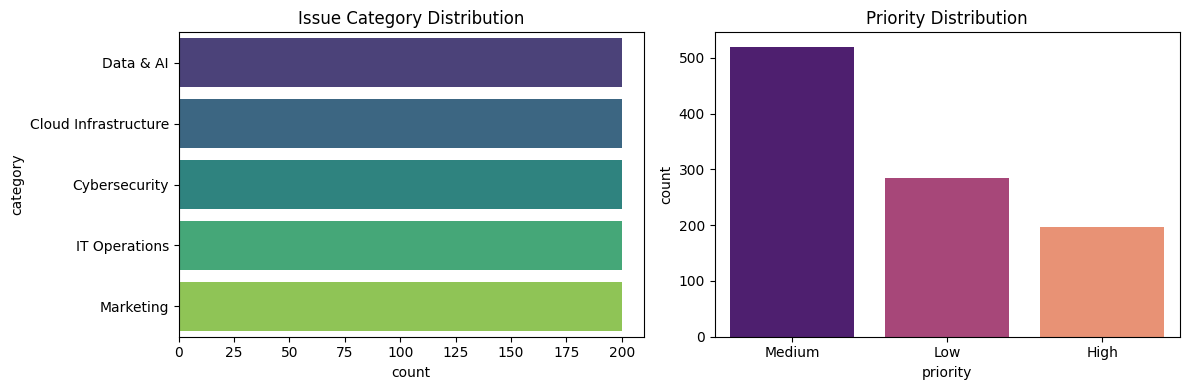

In [2]:
# Basic overview
print(df.info())
print("\nMissing values per column:\n", df.isnull().sum())

# Label and priority distributions
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(y=df['category'], order=df['category'].value_counts().index, ax=axes[0], palette="viridis")
axes[0].set_title("Issue Category Distribution")
sns.countplot(x=df['priority'], order=df['priority'].value_counts().index, ax=axes[1], palette="magma")
axes[1].set_title("Priority Distribution")
plt.tight_layout()
plt.show()


## 1. Preprocessing and Feature Engineering

After exploring the dataset, we prepare the text and labels for modeling.

We perform:
- **Text preparation** — cleaning and standardizing the issue descriptions.  
- **Label encoding** — converting department categories into numerical labels where needed.  
- **Train/test split** — stratified to preserve category proportions.

This ensures that our models train on balanced, representative samples and that evaluation metrics remain consistent across classes.



In [3]:
from sklearn.model_selection import train_test_split
import yaml

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

df = pd.read_csv(cfg["data"]["path"])
X = df["description"].astype(str)
y = df["category"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=cfg["eval"]["test_size"],
    random_state=cfg["eval"]["random_seed"],
    stratify=y
)

print(f"Training size: {len(X_train)} | Test size: {len(X_test)}")
print("Classes:", y.unique().tolist())


Training size: 800 | Test size: 200
Classes: ['Data & AI', 'Cloud Infrastructure', 'Cybersecurity', 'IT Operations', 'Marketing']


## 2. Baseline Model — TF-IDF + Logistic Regression

We begin with a **classical baseline** that combines **TF-IDF vectorization** with **Logistic Regression**.

- **TF-IDF (Term Frequency–Inverse Document Frequency)** converts raw text into numerical vectors by measuring how important each word is within a document compared to the entire dataset.
- **Logistic Regression** then learns to map these word-weighted vectors to the issue categories.

This setup provides:
- A fast, interpretable starting point for text classification.


In [4]:
import os, sys
sys.path.append(os.path.abspath('..'))

In [7]:
from src.eval.evaluate import run_tfidf_lr

result_lr = run_tfidf_lr(X_train, X_test, y_train, y_test, cfg)
pd.DataFrame([result_lr])


[12:05:17] Training TF-IDF + Logistic Regression...
Saved results for tfidf_lr to ../results/tfidf_lr


,accuracy,precision,recall,f1_macro,model,time_sec
0,0.845,0.850471,0.845,0.842896,TFIDF_LR,2.23


## 3. TF-IDF + SVM

We now train a Support Vector Machine using the same TF-IDF features.  
SVMs usually perform better than Logistic Regression in text tasks because they handle high-dimensional data well.  
They work by finding the best boundary that separates the issue categories.

In [8]:
from src.eval.evaluate import run_svm

result_svm = run_svm(X_train, X_test, y_train, y_test, cfg)
pd.DataFrame([result_svm])


[12:06:00] Training TF-IDF + SVM...
Saved results for tfidf_svm to ../results/tfidf_svm


,accuracy,precision,recall,f1_macro,model,time_sec
0,0.835,0.835203,0.835,0.833133,TFIDF_SVM,0.03


## 4. SBERT + kNN

Here we use **Sentence-BERT** embeddings to capture the meaning of each issue, not just word counts.  
Then, a **k-Nearest Neighbors (kNN)** classifier finds the most similar past issues (using cosine similarity)  
and assigns the label that appears most often among them.



In [9]:
from src.eval.evaluate import run_sbert_knn

result_sbert = run_sbert_knn(X_train, X_test, y_train, y_test, cfg)
pd.DataFrame([result_sbert])


[12:06:04] Training SBERT + kNN...
Saved results for sbert_knn to ../results/sbert_knn


,accuracy,precision,recall,f1_macro,model,time_sec
0,0.785,0.790289,0.785,0.785467,SBERT_KNN,2.91


## 5. Azure OpenAI Embeddings + kNN

Finally, we use **embeddings from Azure OpenAI**, which come from large language models trained on diverse data.  
These embeddings already capture broad world knowledge,  
so the model can classify new issues **without any extra fine-tuning** using a simple kNN approach.


In [10]:
from src.eval.evaluate import run_openai_knn

result_openai = run_openai_knn(X_train, X_test, y_train, y_test, cfg)
pd.DataFrame([result_openai])


[12:06:18] Training Azure OpenAI + kNN...

[Azure+kNN] Loading dataset...
[Azure+kNN] Generating Azure OpenAI embeddings...
[Azure+kNN] Embeddings generated in 53.86 seconds
[Azure+kNN] Training kNN classifier...
[Azure+kNN]  Macro-F1: 0.820
[Azure+kNN] Total runtime (incl. embedding): 53.98s
Saved results for openai_knn to ../results/openai_knn


,model,f1_macro,time_sec
0,Azure_KNN,0.820434,53.98


## 6. TF-IDF + XGBoost

We also test **XGBoost**, a tree-based model that captures non-linear relationships in the TF-IDF features.  
It’s fast, scalable, and often boosts performance when simple linear models reach their limits.


In [5]:
from src.eval.evaluate import run_xgboost

res_xgb = run_xgboost(X_train, X_test, y_train, y_test, cfg)
pd.DataFrame([res_xgb])

[12:55:04] Training TF-IDF + XGBoost...


/mnt/c/Users/JVidias/Documents/genai/multi-domain-issues-to-actions/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [12:55:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Saved results for tfidf_xgboost to ../results/tfidf_xgboost
[12:55:05]  Done TF-IDF + XGBoost in 1.17s | F1: 0.803


,accuracy,precision,recall,f1_macro,model,time_sec
0,0.805,0.810738,0.805,0.803393,TFIDF_XGBOOST,1.17


,accuracy,precision,recall,f1_macro,model,time_sec
0,0.845,0.855561,0.845,0.846609,MiniLM_FineTuned_kNN,4.46
3,0.845,0.850471,0.845,0.842896,TFIDF_LR,2.23
4,0.835,0.835203,0.835,0.833133,TFIDF_SVM,0.03
1,NaN,NaN,NaN,0.820434,Azure_KNN,53.98
5,0.805,0.810738,0.805,0.803393,TFIDF_XGBOOST,1.17
2,0.785,0.790289,0.785,0.785467,SBERT_KNN,2.91


/tmp/ipykernel_561926/1173264293.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="f1_macro", y="model", palette="crest")


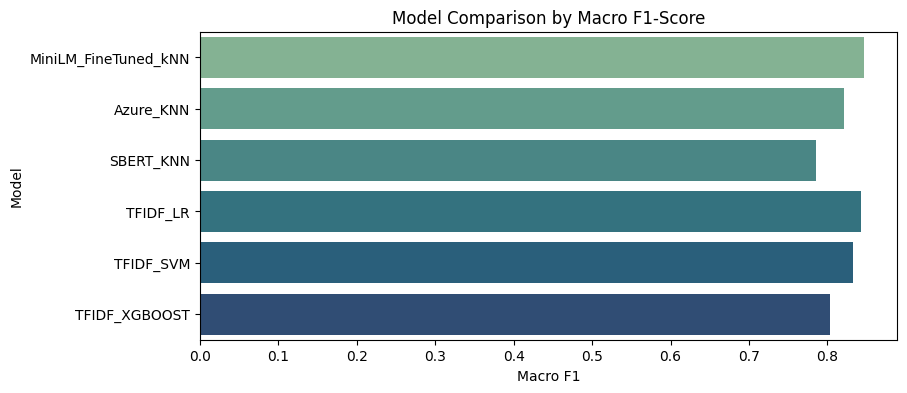

In [7]:
from src.eval.evaluate import aggregate_results
import seaborn as sns
import matplotlib.pyplot as plt

results_df = aggregate_results()
display(results_df.sort_values(by="f1_macro", ascending=False))

plt.figure(figsize=(9, 4))
sns.barplot(data=results_df, x="f1_macro", y="model", palette="crest")
plt.title("Model Comparison by Macro F1-Score")
plt.xlabel("Macro F1")
plt.ylabel("Model")
plt.show()


## Fine-Tuning the MiniLM Model

In this step, we fine-tune the **all-MiniLM-L6-v2** model on our synthetic issue dataset.  
The goal is to adapt the model’s embeddings to our own business domains  
(Cybersecurity, Marketing, Data & AI, Cloud, and IT Operations).

Fine-tuning helps the model:
- Learn domain-specific wording and context  
- Improve representation of similar issues  
- Strengthen classification and retrieval accuracy

Steps:
- The dataset of issue descriptions and categories is split into training and validation sets.
- Each issue text is encoded into a dense vector representation.
- A Softmax classification layer is added on top of the encoder to predict one of the department categories.
- The model is trained using cross-entropy loss, adjusting the weights of MiniLM so that similar issues map closer together in the embedding space.

In [5]:
import yaml
import src.fine_tuning.fine_tune_minilm as ft
sys.path.append(os.path.abspath('..'))
with open('../configs/config.yaml') as f:
    cfg = yaml.safe_load(f)

ft.fine_tune_minilm(cfg)


Fine-tuning all-MiniLM-L6-v2 for 3 epochs...


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

/mnt/c/Users/JVidias/Documents/genai/multi-domain-issues-to-actions/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


Fine-tuned model saved to ../results/models/minilm_finetuned


(SentenceTransformer(
   (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
   (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
   (2): Normalize()
 ),
 LabelEncoder())

## 6 Fine-Tuned MiniLM + kNN Evaluation

Here, we test the **domain-adapted MiniLM embeddings** after fine-tuning.  
We train a lightweight **kNN classifier** on the fine-tuned embeddings
and evaluate it on the same test split as other models.

**Workflow:**
1. Load fine-tuned MiniLM model  
2. Encode training and test sets into embeddings  
3. Train kNN classifier (k=3)  
4. Evaluate accuracy, precision, recall, and F1  
5. Save metrics under results/eval/finetuned_minilm_knn.csv

In [6]:
from src.eval.evaluate import run_finetuned_minilm_knn

metrics_ft_minilm = run_finetuned_minilm_knn(X_train, X_test, y_train, y_test, cfg)
pd.DataFrame([metrics_ft_minilm])

[20:18:24] Evaluating Fine-Tuned MiniLM + kNN...
 Fine-tuned MiniLM embeddings generated and kNN trained in 3.12s
Saved results for finetuned_minilm_knn to ../results/finetuned_minilm_knn


,accuracy,precision,recall,f1_macro,model,time_sec
0,0.845,0.855561,0.845,0.846609,MiniLM_FineTuned_kNN,4.46


## 7 Model Comparison and Metrics Aggregation

Now that all models have been trained and their results saved,  
we aggregate them into a single table and visualize the trade-off between performance and runtime.


,accuracy,precision,recall,f1_macro,model,time_sec
0,0.845,0.855561,0.845,0.846609,MiniLM_FineTuned_kNN,4.46
3,0.845,0.850471,0.845,0.842896,TFIDF_LR,2.23
4,0.835,0.835203,0.835,0.833133,TFIDF_SVM,0.03
1,NaN,NaN,NaN,0.820434,Azure_KNN,53.98
5,0.805,0.810738,0.805,0.803393,TFIDF_XGBOOST,1.17
2,0.785,0.790289,0.785,0.785467,SBERT_KNN,2.91


/tmp/ipykernel_561926/1173264293.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="f1_macro", y="model", palette="crest")


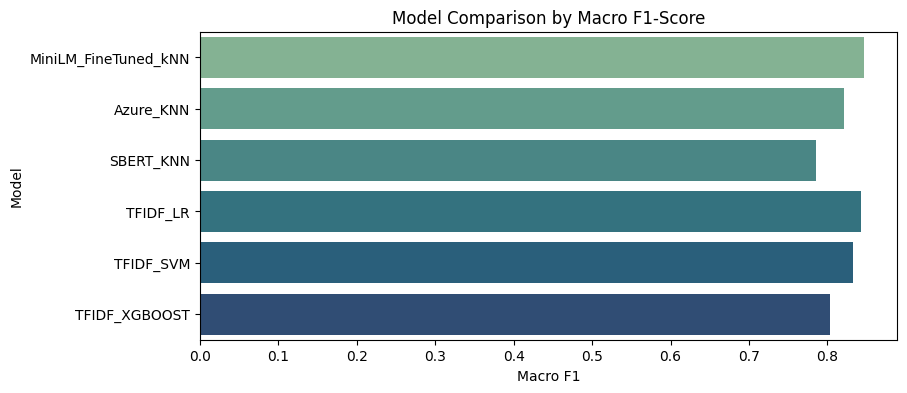

In [8]:
from src.eval.evaluate import aggregate_results
import seaborn as sns
import matplotlib.pyplot as plt

results_df = aggregate_results()
display(results_df.sort_values(by="f1_macro", ascending=False))

plt.figure(figsize=(9, 4))
sns.barplot(data=results_df, x="f1_macro", y="model", palette="crest")
plt.title("Model Comparison by Macro F1-Score")
plt.xlabel("Macro F1")
plt.ylabel("Model")
plt.show()


## Results & Insights

Across all models, **TF-IDF + Logistic Regression** and the **fine-tuned MiniLM + kNN** performed the best (F1 ≈ 0.84–0.85).  
This shows that even lightweight text models can be very effective when data is well-structured.

**Key takeaways:**
- Linear models (LogReg, SVM) remain strong baselines for structured text.  
- Fine-tuned transformers slightly improve results and capture more context.  
- LLM-based embeddings (Azure) are flexible but slower to compute.  

---

## Synthetic Data Reflection

The dataset was created synthetically with LLM prompts.  
It provides balance and realism for testing, but real-world data would be noisier and more varied.  
This setup was ideal for **experimenting quickly and demonstrating workflow design**.

---

## Future Directions

- Fine-tune transformer models further on larger, more realistic datasets.  
- Add **RAG** (Retrieval-Augmented Generation) for context-based action suggestions.  
- Extend to **helpdesk or ticket-routing systems** in enterprise use.

---

## Final Note

This project demonstrates how analytics, ML, and generative AI can work together  
to build interpretable, domain-adaptable AI solutions for real business tasks.
